In [1]:
import torch
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

words = open('../data/names.txt', 'r').read().splitlines()
print(len(words))

cuda
32033


In [2]:
# encode chars to integers
chars = sorted(list(set(''.join(words))))
stoi = { ch:i+1 for i,ch in enumerate(chars)}
stoi['.'] = 0
itos = { i:ch for ch,i in stoi.items()}
vocab_size = len(itos)

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

In [3]:
# hyperparameters
block_size = 16
batch_size = 32

emb_size = 64
n_hidden = 64

In [4]:
# build dataset
def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        # sliding window
        for ch in w + '.':
            ix = stoi[ch] # encode(ch)
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

n1 = int(0.9*len(words))

X, Y = build_dataset(words)
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:])

def get_batch(split):
    dataX = Xtr if split == 'train' else Xval
    dataY = Ytr if split == 'train' else Yval

    ix = torch.randint(low=0, high=dataX.shape[0], size=(batch_size, ))
    x = torch.stack([dataX[i] for i in ix])
    y = torch.stack([dataY[i] for i in ix])

    x, y = x.to(device), y.to(device)
    return x, y


print(X[:5])
print(Y[:5])
len(Xtr)

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  5],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  5, 13],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  5, 13, 13],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  5, 13, 13,  1]])
tensor([ 5, 13, 13,  1,  0])


205411

In [5]:
# create embedding -> FFN (tanh non-linearity)
tok_emb = torch.randn((vocab_size, emb_size), device=device)
pos_emb = torch.randn((block_size, emb_size), device=device)
W1 = torch.randn((4 * emb_size, n_hidden), device=device)
B1 = torch.randn((n_hidden), device=device)

W2 = torch.randn((4 * emb_size, n_hidden), device=device)
B2 = torch.randn((n_hidden), device=device)

W3 = torch.randn((n_hidden, vocab_size), device=device)
B3 = torch.randn((vocab_size), device=device)
parameters = [tok_emb, pos_emb, W1, B1, W2, B2, W3, B3]
for p in parameters:
    p.requires_grad = True

In [6]:
Xb, Yb = get_batch('train')
emb = tok_emb[Xb]
emb += pos_emb

# ---------------------------------------------------------------
tok_emb.shape # 32, 8,64
pos_emb.shape # 8, 64
x.shape # GOAL 32, 512 (8*64 = 512)
# ---------------------------------------------------------------

flatten_factor = 4
x = emb
# print(x.shape)

B, T, C = x.shape
x = x.view(B, T // flatten_factor, C * flatten_factor)
if x.shape[1] == 1:
    x = x.squeeze(1)
# linear tanh
print(x.shape)
print(W1.shape)
x = torch.tanh(x @ W1 + B1)

print(x.shape)

NameError: name 'x' is not defined

### Major changes from initial V1 MLP.

* Instead of simple crushing of (B, T*C) concat, we will do a (B, T//2, C * 2) repeatedly until we achieve (B, 1, T * C) -> (B, T * C).
* flatten -> linear -> normalization (layer or batch) -> tanh

In [ ]:
# training loop
flatten_factor = 4
max_iters = 100000
lr = 4e-6
lossi = []

In [19]:
for i in range(max_iters):
    Xb, Yb = get_batch('train') # (B, T) -> (batch_size, block_size)

    emb = tok_emb[Xb] # (B, T, C) -> (batch_size, block_size, emb_size)
    pos = pos_emb # (T, C) -> (1, block_size, emb_size)
    emb += pos

    # FLATTEN 4 (B, T//4, C*4) -> (batch_size, block_size//4, emb_size*4)
    x = emb
    B, T, C = x.shape
    x = x.view(B, T // flatten_factor, C * flatten_factor)
    x = torch.tanh(x @ W1 + B1)

    B, T, C = x.shape
    x = x.view(B, T // flatten_factor, C * flatten_factor)
    x = torch.tanh(x @ W2 + B2)
    x = x.squeeze(1)

    x = x @ W3 + B3

    # cross entropy loss (negative log likelihood)
    # print(x.shape)
    # print(Yb.shape)
    loss = F.cross_entropy(x, Yb)

    # AdamW
    optimizer = torch.optim.AdamW(parameters, lr=lr)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if i % (max_iters // 5) == 0:
        print(loss.item())
    lossi.append(loss.item())

9.656468391418457
6.9975361824035645
6.476431846618652
6.9951019287109375
8.574392318725586


In [ ]:
torch.save(parameters, 'parametersV2.pt')
parameters = torch.load('parametersV2.pt', weights_only=True)
tok_emb, pos_emb, W1, B1, W2, B2, W3, B3 = parameters

for p in parameters:
    p.requires_grad = True

30356.09631399776

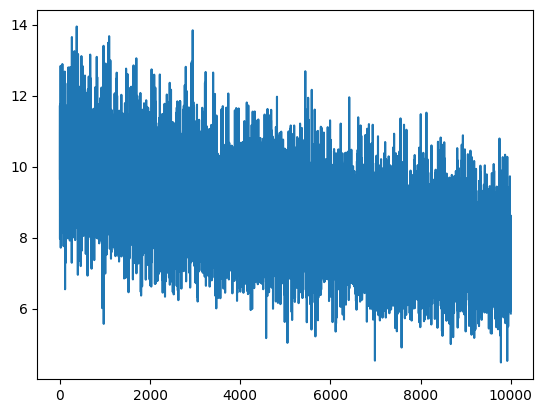

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(lossi)
10 ** min(lossi)

In [ ]:
# generation
temp = 1.0

@torch.no_grad()
def generate():
    out = []
    context = [0] * block_size
    
    initial_context = "bren"
    out = encode(initial_context)
    context = encode("............" + initial_context) 
    while True:
        Xgen = torch.tensor([context], device=device)
        emb = tok_emb[Xgen] 
        pos = pos_emb 
        emb += pos

        # FLATTEN 4 (B, T//4, C*4) -> (batch_size, block_size//4, emb_size*4)
        x = emb
        B, T, C = x.shape
        x = x.view(B, T // flatten_factor, C * flatten_factor)
        x = torch.tanh(x @ W1 + B1)

        B, T, C = x.shape
        x = x.view(B, T // flatten_factor, C * flatten_factor)
        x = torch.tanh(x @ W2 + B2)
        x = x.squeeze(1)

        x = x @ W3 + B3

        # calc probs + temp -> sample
        probs = F.softmax(x / temp, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(out)
    print(decode(out))

for _ in range(5):
    generate()

    


[2, 18, 5, 14, 12, 9, 0]
brenli.
[2, 18, 5, 14, 5, 9, 14, 0]
brenein.
[2, 18, 5, 14, 5, 12, 25, 0]
brenely.
[2, 18, 5, 14, 0]
bren.
[2, 18, 5, 14, 1, 0]
brena.
